In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/European_Bank.csv')
df = df.drop(columns=['Year'])

df['AgeBand'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 92], labels=['18-30', '31-45', '46-60', '61+'])
df['HighBalance'] = (df['Balance'] > df['Balance'].median()).astype(int)

def classify_engagement(row):
    if row['IsActiveMember'] == 1:
        if row['NumOfProducts'] >= 2:
            return 'Active Engaged'
        else:
            return 'Active Low-Product'
    else:
        if row['HighBalance'] == 1:
            return 'Inactive High-Balance'
        else:
            return 'Inactive Disengaged'

df['EngagementProfile'] = df.apply(classify_engagement, axis=1)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeBand,HighBalance,EngagementProfile
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,31-45,0,Active Low-Product
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,31-45,0,Active Low-Product
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,31-45,1,Inactive High-Balance
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-45,0,Inactive Disengaged
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,31-45,1,Active Low-Product


               Count  ChurnRate
NumOfProducts                  
1               5084     0.2771
2               4590     0.0758
3                266     0.8271
4                 60     1.0000


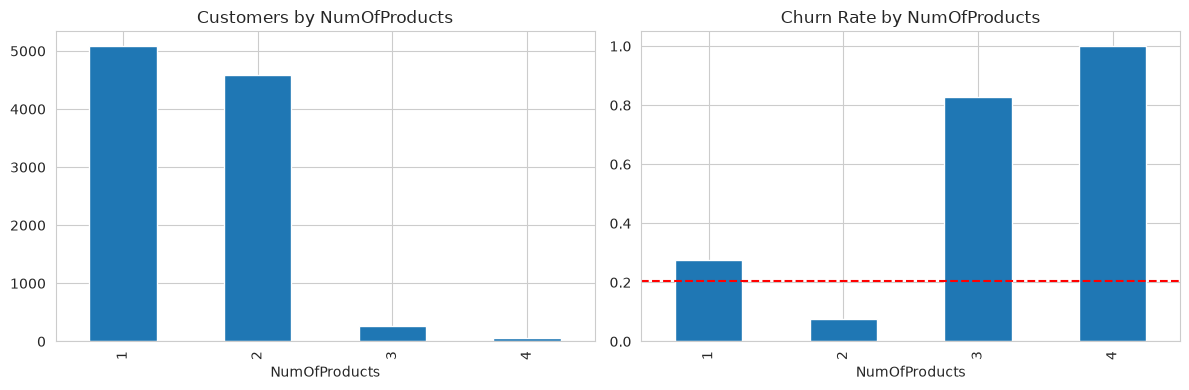

In [2]:
product_counts = df['NumOfProducts'].value_counts().sort_index()
churn_by_products = df.groupby('NumOfProducts')['Exited'].mean().sort_index()

summary = pd.DataFrame({'Count': product_counts, 'ChurnRate': churn_by_products.round(4)})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
product_counts.plot(kind='bar', ax=axes[0], title='Customers by NumOfProducts')
churn_by_products.plot(kind='bar', ax=axes[1], title='Churn Rate by NumOfProducts')
axes[1].axhline(df['Exited'].mean(), color='red', linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/figures/churn_by_numproducts.png', dpi=150)
plt.show()

ProductTier
Multi (2+)    0.127746
Single (1)    0.277144
Name: Exited, dtype: float64


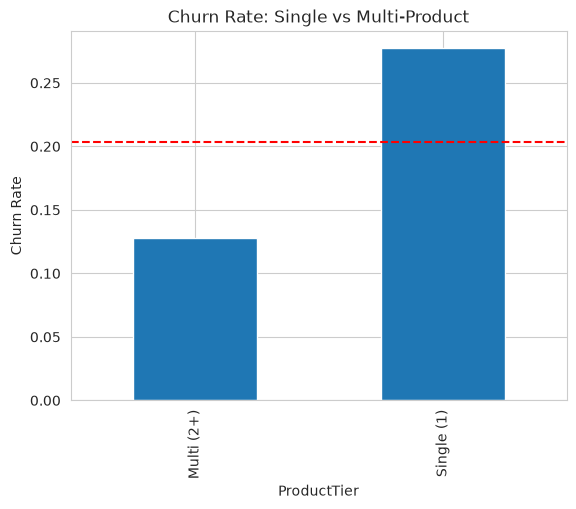

In [3]:
df['ProductTier'] = df['NumOfProducts'].apply(lambda x: 'Single (1)' if x == 1 else 'Multi (2+)')

churn_by_tier = df.groupby('ProductTier')['Exited'].mean()
print(churn_by_tier)

churn_by_tier.plot(kind='bar', title='Churn Rate: Single vs Multi-Product', ylabel='Churn Rate')
plt.axhline(df['Exited'].mean(), color='red', linestyle='--')
plt.savefig('../outputs/figures/churn_single_vs_multi.png', dpi=150)
plt.show()


In [4]:
# Is NumOfProducts confounded with inactivity?
active_by_products = pd.crosstab(df['NumOfProducts'], df['IsActiveMember'], normalize='index') * 100
print("IsActiveMember % within each NumOfProducts group:\n", active_by_products.round(1))

print()

# Isolate the 3-4 product customers specifically
high_product = df[df['NumOfProducts'] >= 3]
print(f"3-4 product customers: {len(high_product)} ({len(high_product)/len(df)*100:.1f}% of base)")
print(f"Churn rate: {high_product['Exited'].mean()*100:.1f}%")
print(f"% inactive: {(high_product['IsActiveMember']==0).mean()*100:.1f}%")

IsActiveMember % within each NumOfProducts group:
 IsActiveMember     0     1
NumOfProducts             
1               49.6  50.4
2               46.7  53.3
3               57.5  42.5
4               51.7  48.3

3-4 product customers: 326 (3.3% of base)
Churn rate: 85.9%
% inactive: 56.4%


HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64


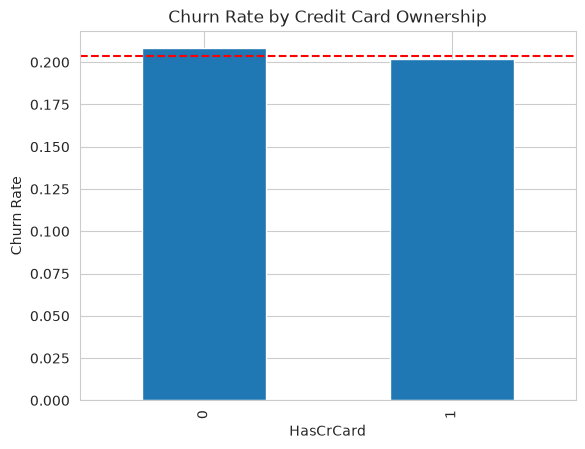

In [5]:
churn_by_card = df.groupby('HasCrCard')['Exited'].mean()
print(churn_by_card)

churn_by_card.plot(kind='bar', title='Churn Rate by Credit Card Ownership', ylabel='Churn Rate')
plt.axhline(df['Exited'].mean(), color='red', linestyle='--')
plt.savefig('../outputs/figures/churn_by_hascrcard.png', dpi=150)
plt.show()

In [6]:
geo_by_products = pd.crosstab(df['NumOfProducts'], df['Geography'], normalize='index') * 100
print("Geography % within each NumOfProducts group:\n", geo_by_products.round(1))

Geography % within each NumOfProducts group:
 Geography      France  Germany  Spain
NumOfProducts                        
1                49.4     26.5   24.0
2                51.6     22.7   25.8
3                39.1     36.1   24.8
4                48.3     40.0   11.7


## Product Utilization Summary

- Churn rate rises sharply with product count: 1 product = 27.7%, 2 products = 7.6% (most loyal segment), 3 products = 82.7%, 4 products = 100%. The 3-4 product group is only 3.3% of the base but churns almost universally.
- Neither inactivity (56.4% inactive vs ~50% baseline) nor geography (40% German vs ~25% baseline) is large enough to explain the spike — both are mild skews against a near-total churn effect. The cause is likely something not captured in this dataset (e.g. forced bundling, dissatisfaction with an over-sold relationship) and should be flagged as an open question, not a solved one.
- The single vs multi-product split (27.7% vs 12.8%) is misleading in isolation — it merges the most loyal group (2 products) with the least loyal (3-4 products). Exact product count is the meaningful cut, not a binary tier.
- HasCrCard shows no meaningful churn difference (20.8% vs 20.2%) — card ownership is not a retention lever.